In [2]:
# ============================================================
# Notebook 8: Model Explainability / XAI
# Step 1: Load final model, data, preprocessor, and feature names
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import joblib

from sklearn.base import BaseEstimator, TransformerMixin

warnings.filterwarnings("ignore")

# 1. Define RareCategoryGrouper before loading preprocessor

class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, min_frequency=10, rare_label="Rare"):
        self.min_frequency = min_frequency
        self.rare_label = rare_label

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).astype(str)

        self.frequent_categories_ = []

        for column in X_df.columns:
            value_counts = X_df[column].value_counts(dropna=False)
            frequent_categories = value_counts[
                value_counts >= self.min_frequency
            ].index.astype(str).tolist()

            self.frequent_categories_.append(frequent_categories)

        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).astype(str).copy()

        for column_index, column in enumerate(X_df.columns):

            if isinstance(self.frequent_categories_, list):
                frequent_categories = self.frequent_categories_[column_index]

            elif isinstance(self.frequent_categories_, dict):
                frequent_categories = self.frequent_categories_.get(
                    column,
                    []
                )

            else:
                raise TypeError(
                    "Unsupported frequent_categories_ format."
                )

            X_df[column] = np.where(
                X_df[column].isin(frequent_categories),
                X_df[column],
                self.rare_label
            )

        return X_df

# 2. Detect project root

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT = None

for candidate in [CURRENT_DIRECTORY, *CURRENT_DIRECTORY.parents]:
    if (candidate / "data" / "processed" / "diabetic_modeling_data_final.csv").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate project root. Make sure this notebook is inside the project folder."
    )

print(f"Project root detected: {PROJECT_ROOT}")

# 3. Define paths

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "diabetic_modeling_data_final.csv"
SCHEMA_PATH = PROJECT_ROOT / "data" / "processed" / "model_feature_schema.json"
SPLIT_PATH = PROJECT_ROOT / "data" / "processed" / "patient_split_assignments.csv"

MODELS_PATH = PROJECT_ROOT / "models"
ARTIFACTS_PATH = PROJECT_ROOT / "artifacts"
METRICS_PATH = PROJECT_ROOT / "outputs" / "metrics"
FIGURES_PATH = PROJECT_ROOT / "outputs" / "figures"

METRICS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)


# 4. Load final Tuned XGBoost model

FINAL_MODEL_PATH = MODELS_PATH / "notebook_6_best_tuned_xgboost.joblib"

if not FINAL_MODEL_PATH.exists():
    FINAL_MODEL_PATH = MODELS_PATH / "notebook_6_selected_final_candidate_model.joblib"

if not FINAL_MODEL_PATH.exists():
    raise FileNotFoundError(
        "Final Tuned XGBoost model file not found in models folder."
    )

final_model = joblib.load(FINAL_MODEL_PATH)

print(f"Final model loaded from: {FINAL_MODEL_PATH}")

# 5. Load fitted preprocessor

PREPROCESSOR_PATH = MODELS_PATH / "notebook_4_fitted_preprocessor.joblib"

if not PREPROCESSOR_PATH.exists():
    raise FileNotFoundError(
        "Fitted preprocessor file not found: notebook_4_fitted_preprocessor.joblib"
    )

preprocessor = joblib.load(PREPROCESSOR_PATH)

print(f"Fitted preprocessor loaded from: {PREPROCESSOR_PATH}")

# 6. Load dataset, schema, and split assignments

df = pd.read_csv(DATA_PATH)

with open(SCHEMA_PATH, "r") as file:
    feature_schema = json.load(file)

split_assignments = pd.read_csv(SPLIT_PATH)

numeric_features = feature_schema["numeric_model_features"]
categorical_features = feature_schema["categorical_model_features"]
target_column = feature_schema["target_column"]
group_split_column = feature_schema["group_split_column"]

predictor_columns = numeric_features + categorical_features

print("\nData loaded.")
print(f"Dataset shape: {df.shape}")
print(f"Numeric predictors: {len(numeric_features)}")
print(f"Categorical predictors: {len(categorical_features)}")
print(f"Total raw predictors: {len(predictor_columns)}")

# 7. Prepare patient-level split safely

patient_level_splits = (
    split_assignments[[group_split_column, "split"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

df_with_split = df.merge(
    patient_level_splits,
    on=group_split_column,
    how="left",
    validate="many_to_one"
)

if df_with_split["split"].isna().sum() > 0:
    raise ValueError(
        "Some rows do not have split assignments."
    )

train_df = df_with_split[df_with_split["split"] == "train"].copy()
validation_df = df_with_split[df_with_split["split"] == "validation"].copy()
test_df = df_with_split[df_with_split["split"] == "test"].copy()

print("\nSplit counts:")
print(df_with_split["split"].value_counts())

# 8. Prepare X and y

X_train_raw = train_df[predictor_columns].copy()
y_train = train_df[target_column].copy()

X_validation_raw = validation_df[predictor_columns].copy()
y_validation = validation_df[target_column].copy()

X_test_raw = test_df[predictor_columns].copy()
y_test = test_df[target_column].copy()

print("\nRaw matrices prepared.")
print(f"X_train_raw shape: {X_train_raw.shape}")
print(f"X_validation_raw shape: {X_validation_raw.shape}")
print(f"X_test_raw shape: {X_test_raw.shape}")

# 9. Apply saved preprocessing

X_train_preprocessed = preprocessor.transform(X_train_raw)
X_validation_preprocessed = preprocessor.transform(X_validation_raw)
X_test_preprocessed = preprocessor.transform(X_test_raw)

print("\nPreprocessing applied.")
print(f"X_train_preprocessed shape: {X_train_preprocessed.shape}")
print(f"X_validation_preprocessed shape: {X_validation_preprocessed.shape}")
print(f"X_test_preprocessed shape: {X_test_preprocessed.shape}")

# 10. Load transformed feature names safely

feature_name_files = list(PROJECT_ROOT.rglob("*transformed*feature*names*.csv"))

if feature_name_files:
    feature_name_path = feature_name_files[0]
    feature_names_df = pd.read_csv(feature_name_path)

    if "feature_name" in feature_names_df.columns:
        transformed_feature_names = feature_names_df["feature_name"].astype(str).tolist()
    elif "transformed_feature_name" in feature_names_df.columns:
        transformed_feature_names = feature_names_df["transformed_feature_name"].astype(str).tolist()
    else:
        transformed_feature_names = feature_names_df.iloc[:, 0].astype(str).tolist()

    print(f"\nTransformed feature names loaded from: {feature_name_path}")

else:
    try:
        transformed_feature_names = preprocessor.get_feature_names_out().astype(str).tolist()
        print("\nTransformed feature names extracted from preprocessor.")
    except Exception:
        transformed_feature_names = [
            f"feature_{index}"
            for index in range(X_train_preprocessed.shape[1])
        ]
        print("\nFeature names could not be loaded, so generic names were created.")

if len(transformed_feature_names) != X_train_preprocessed.shape[1]:
    raise ValueError(
        f"Feature name count mismatch. "
        f"Feature names: {len(transformed_feature_names)}, "
        f"Preprocessed columns: {X_train_preprocessed.shape[1]}"
    )

print(f"Total transformed features: {len(transformed_feature_names)}")

# 11. Create DataFrame versions for explainability

X_train_explain = pd.DataFrame(
    X_train_preprocessed.toarray()
    if hasattr(X_train_preprocessed, "toarray")
    else X_train_preprocessed,
    columns=transformed_feature_names,
    index=X_train_raw.index
)

X_validation_explain = pd.DataFrame(
    X_validation_preprocessed.toarray()
    if hasattr(X_validation_preprocessed, "toarray")
    else X_validation_preprocessed,
    columns=transformed_feature_names,
    index=X_validation_raw.index
)

X_test_explain = pd.DataFrame(
    X_test_preprocessed.toarray()
    if hasattr(X_test_preprocessed, "toarray")
    else X_test_preprocessed,
    columns=transformed_feature_names,
    index=X_test_raw.index
)

print("\nExplainability DataFrames created.")
print(f"X_train_explain shape: {X_train_explain.shape}")
print(f"X_validation_explain shape: {X_validation_explain.shape}")
print(f"X_test_explain shape: {X_test_explain.shape}")


# 12. Final confirmation

print("\nNotebook 8 Step 1 completed successfully.")
print("- Final Tuned XGBoost model loaded.")
print("- Saved preprocessor loaded.")
print("- Train, validation, and test sets prepared.")
print("- Transformed feature names loaded.")
print("- Explainability matrices created.")

Project root detected: C:\Users\pradh\Documents\hospital-readmission-project
Final model loaded from: C:\Users\pradh\Documents\hospital-readmission-project\models\notebook_6_best_tuned_xgboost.joblib
Fitted preprocessor loaded from: C:\Users\pradh\Documents\hospital-readmission-project\models\notebook_4_fitted_preprocessor.joblib

Data loaded.
Dataset shape: (99343, 46)
Numeric predictors: 8
Categorical predictors: 35
Total raw predictors: 43

Split counts:
split
train         69467
test          14976
validation    14900
Name: count, dtype: int64

Raw matrices prepared.
X_train_raw shape: (69467, 43)
X_validation_raw shape: (14900, 43)
X_test_raw shape: (14976, 43)

Preprocessing applied.
X_train_preprocessed shape: (69467, 179)
X_validation_preprocessed shape: (14900, 179)
X_test_preprocessed shape: (14976, 179)

Transformed feature names loaded from: C:\Users\pradh\Documents\hospital-readmission-project\reports\modeling\transformed_feature_names.csv
Total transformed features: 179



Top 25 XGBoost transformed feature importances
----------------------------------------------------------------------------------------------------
 rank                                                         feature  importance
    1                                       numeric__number_inpatient    0.052366
    2                         categorical__discharge_disposition_id_1    0.047910
    3                         categorical__discharge_disposition_id_5    0.027834
    4                                       numeric__number_emergency    0.012451
    5                        categorical__discharge_disposition_id_22    0.011658
    6                        categorical__discharge_disposition_id_15    0.011627
    7                       categorical__diag_1_group_Musculoskeletal    0.011015
    8                             categorical__diag_2_group_Neoplasms    0.010371
    9                         categorical__discharge_disposition_id_4    0.010336
   10                           

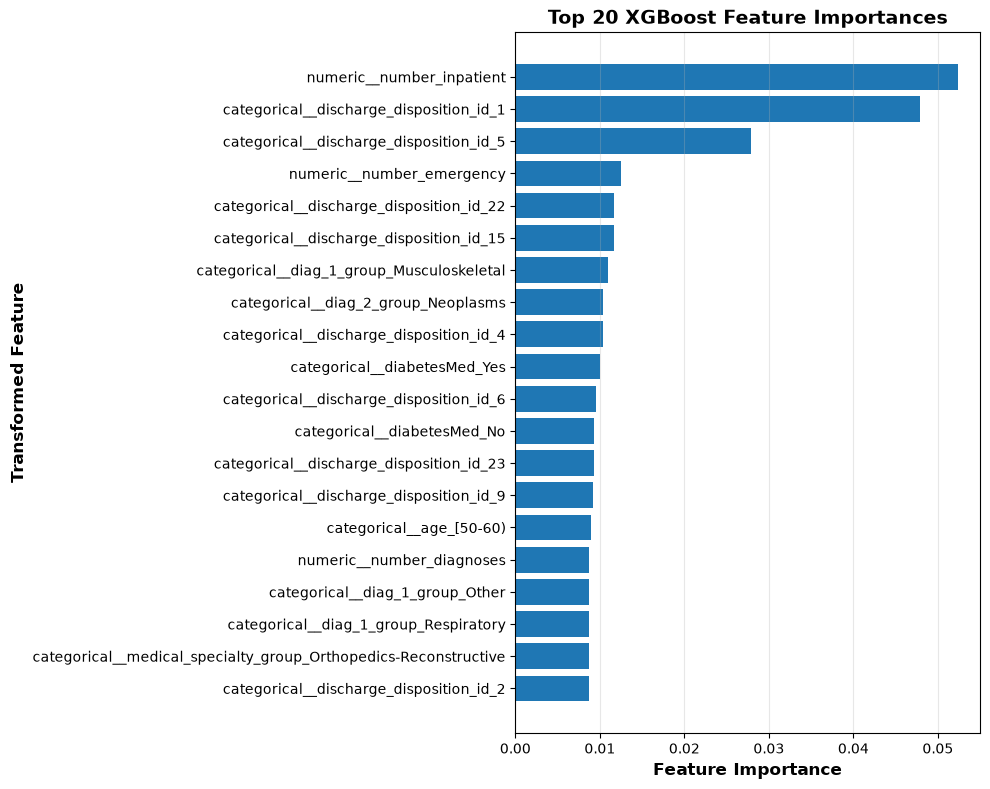


Feature importance outputs saved successfully.
CSV: C:\Users\pradh\Documents\hospital-readmission-project\outputs\metrics\notebook_8_xgboost_feature_importance.csv
Plot: C:\Users\pradh\Documents\hospital-readmission-project\outputs\figures\notebook_8_top_20_xgboost_feature_importance.png


In [3]:
# Step 2: XGBoost feature importance

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Extract feature importance from final XGBoost model

if not hasattr(final_model, "feature_importances_"):
    raise AttributeError(
        "The final model does not have feature_importances_. "
        "Check that the loaded model is the tuned XGBoost model."
    )

feature_importance_df = pd.DataFrame(
    {
        "feature": transformed_feature_names,
        "importance": final_model.feature_importances_,
    }
)

feature_importance_df = (
    feature_importance_df
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance_df["rank"] = np.arange(
    1,
    len(feature_importance_df) + 1
)

# 2. Save full feature importance table

feature_importance_path = (
    METRICS_PATH
    / "notebook_8_xgboost_feature_importance.csv"
)

feature_importance_df.to_csv(
    feature_importance_path,
    index=False
)

print("Top 25 XGBoost transformed feature importances")
print("-" * 100)

print(
    feature_importance_df[
        [
            "rank",
            "feature",
            "importance",
        ]
    ]
    .head(25)
    .to_string(index=False)
)

# 3. Plot top 20 feature importances

top_n = 20

top_features = (
    feature_importance_df
    .head(top_n)
    .sort_values("importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    top_features["feature"],
    top_features["importance"]
)

ax.set_title(
    "Top 20 XGBoost Feature Importances",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Feature Importance",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Transformed Feature",
    fontsize=12,
    fontweight="bold"
)

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()

feature_importance_plot_path = (
    FIGURES_PATH
    / "notebook_8_top_20_xgboost_feature_importance.png"
)

plt.savefig(
    feature_importance_plot_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# 4. Print saved file locations

print("\nFeature importance outputs saved successfully.")
print(f"CSV: {feature_importance_path}")
print(f"Plot: {feature_importance_plot_path}")

Top original predictors by grouped XGBoost importance
----------------------------------------------------------------------------------------------------
 rank         original_feature  total_importance  max_single_importance  number_transformed_features
    1 discharge_disposition_id          0.172500               0.047910                           17
    2  medical_specialty_group          0.117198               0.008708                           18
    3             diag_1_group          0.068843               0.011015                           10
    4             diag_3_group          0.061927               0.008119                           10
    5                      age          0.058985               0.008921                           10
    6             diag_2_group          0.056961               0.010371                           10
    7         number_inpatient          0.052366               0.052366                            1
    8                     race       

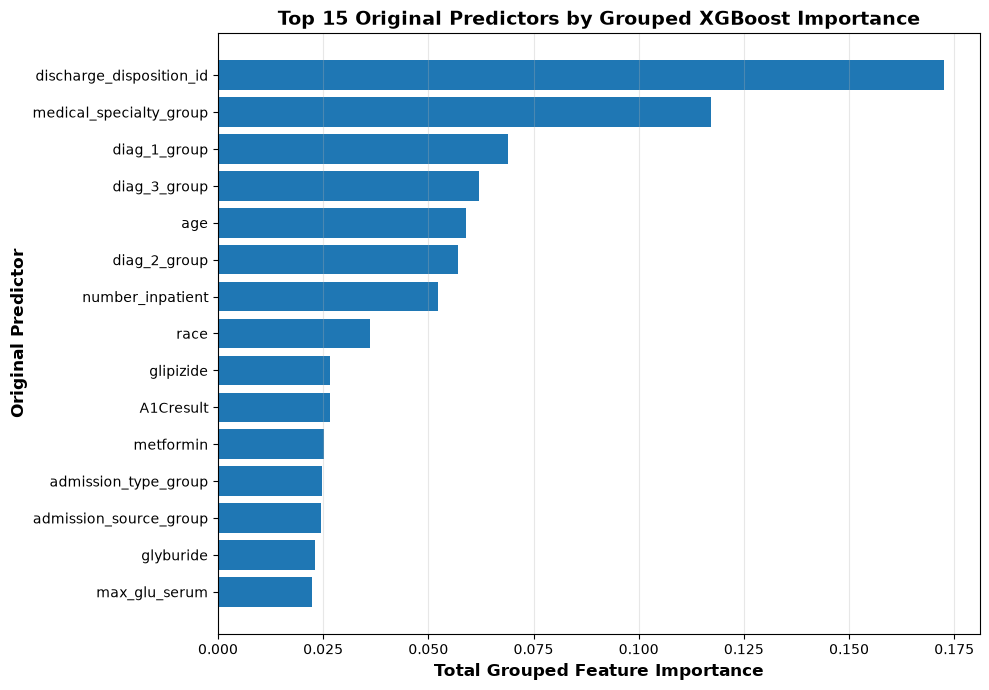


Grouped feature importance outputs saved successfully.
CSV: C:\Users\pradh\Documents\hospital-readmission-project\outputs\metrics\notebook_8_grouped_original_feature_importance.csv
Plot: C:\Users\pradh\Documents\hospital-readmission-project\outputs\figures\notebook_8_top_15_grouped_original_feature_importance.png


In [4]:
# Step 3: Group transformed feature importances by original predictor

import re
import matplotlib.pyplot as plt
import pandas as pd

# 1. Helper function to map transformed feature to original feature

def get_original_feature_name(transformed_feature):
    feature = str(transformed_feature)

    # Remove preprocessing prefixes
    feature = feature.replace("numeric__", "")
    feature = feature.replace("categorical__", "")

    # Numeric features stay as-is
    if feature in numeric_features:
        return feature

    # For categorical one-hot features, match back to original categorical feature
    # Example: discharge_disposition_id_1 -> discharge_disposition_id
    for original_feature in sorted(categorical_features, key=len, reverse=True):
        if feature == original_feature:
            return original_feature

        if feature.startswith(original_feature + "_"):
            return original_feature

    return feature

# 2. Add original feature name

feature_importance_grouped = feature_importance_df.copy()

feature_importance_grouped["original_feature"] = (
    feature_importance_grouped["feature"]
    .apply(get_original_feature_name)
)

# 3. Aggregate importance by original feature

original_feature_importance = (
    feature_importance_grouped
    .groupby("original_feature", as_index=False)
    .agg(
        total_importance=("importance", "sum"),
        max_single_importance=("importance", "max"),
        number_transformed_features=("feature", "count")
    )
    .sort_values("total_importance", ascending=False)
    .reset_index(drop=True)
)

original_feature_importance["rank"] = (
    original_feature_importance.index + 1
)

# Reorder columns
original_feature_importance = original_feature_importance[
    [
        "rank",
        "original_feature",
        "total_importance",
        "max_single_importance",
        "number_transformed_features",
    ]
]

# 4. Save grouped importance table

grouped_importance_path = (
    METRICS_PATH
    / "notebook_8_grouped_original_feature_importance.csv"
)

original_feature_importance.to_csv(
    grouped_importance_path,
    index=False
)

print("Top original predictors by grouped XGBoost importance")
print("-" * 100)

print(
    original_feature_importance
    .head(25)
    .round(6)
    .to_string(index=False)
)

# 5. Plot top 15 original predictors

top_n = 15

top_original_features = (
    original_feature_importance
    .head(top_n)
    .sort_values("total_importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    top_original_features["original_feature"],
    top_original_features["total_importance"]
)

ax.set_title(
    "Top 15 Original Predictors by Grouped XGBoost Importance",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Total Grouped Feature Importance",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Original Predictor",
    fontsize=12,
    fontweight="bold"
)

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()

grouped_importance_plot_path = (
    FIGURES_PATH
    / "notebook_8_top_15_grouped_original_feature_importance.png"
)

plt.savefig(
    grouped_importance_plot_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# 6. Print saved locations

print("\nGrouped feature importance outputs saved successfully.")
print(f"CSV: {grouped_importance_path}")
print(f"Plot: {grouped_importance_plot_path}")

### Grouped Feature Importance Interpretation

After grouping the one-hot encoded features back to their original predictor names, the most important predictors for the final Tuned XGBoost model were discharge disposition, medical specialty group, diagnosis groups, age, and prior inpatient visits.

The highest grouped importance came from `discharge_disposition_id`, which suggests that the patient’s discharge status or destination plays an important role in readmission risk prediction. `medical_specialty_group` was also highly important, indicating that the type of medical specialty involved in care may provide useful information about readmission likelihood.

Diagnosis-related variables, including `diag_1_group`, `diag_2_group`, and `diag_3_group`, were also among the top predictors. This shows that the patient’s primary and secondary diagnosis categories contribute meaningfully to the model’s risk prediction. Age was another important predictor, suggesting that readmission risk varies across age groups.

Prior hospital utilization was also important, especially `number_inpatient`, which represents previous inpatient visits. This aligns with the idea that patients with a history of inpatient visits may have a higher chance of future readmission.

Overall, the grouped feature importance results show that the model is using clinically meaningful information such as discharge status, diagnosis categories, prior hospital utilization, age, and treatment-related variables. These results support the use of the model as a clinical decision-support or risk-screening tool. However, feature importance should be interpreted as model influence, not direct medical causation.

XGBoost SHAP contribution values created successfully.
SHAP values shape: (14976, 179)
Base values shape: (14976,)

Top 25 transformed features by mean absolute SHAP contribution
----------------------------------------------------------------------------------------------------
 rank                                                              feature  mean_absolute_shap  mean_shap
    1                              categorical__discharge_disposition_id_2            0.599496   0.599496
    2                              categorical__discharge_disposition_id_9            0.366495   0.366495
    3                              categorical__discharge_disposition_id_6            0.352865  -0.352865
    4                                  categorical__diag_2_group_Neoplasms            0.317508   0.317508
    5                                            numeric__number_inpatient            0.299546  -0.070047
    6                              categorical__discharge_disposition_id_5          

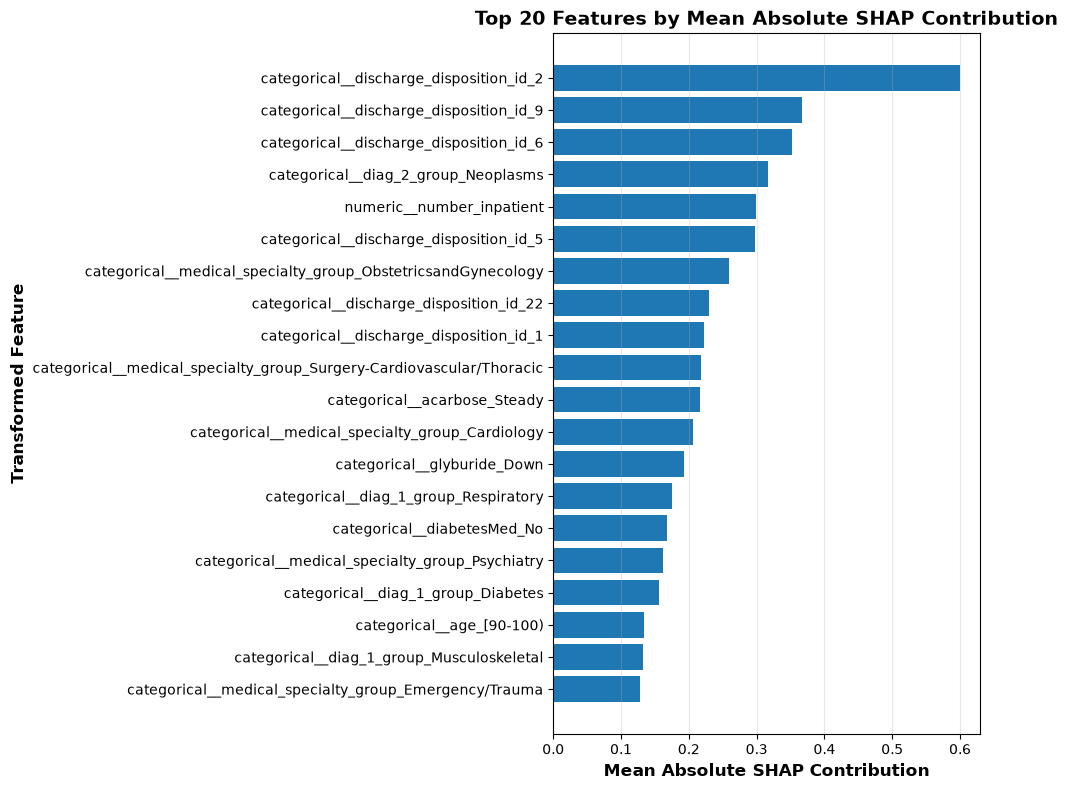


SHAP contribution outputs saved successfully.
CSV: C:\Users\pradh\Documents\hospital-readmission-project\outputs\metrics\notebook_8_xgboost_shap_transformed_feature_importance.csv
Plot: C:\Users\pradh\Documents\hospital-readmission-project\outputs\figures\notebook_8_top_20_xgboost_shap_transformed_importance.png


In [5]:
# Step 4: XGBoost SHAP contribution importance - corrected

import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Create XGBoost DMatrix without feature names

# Reason:
# Some transformed feature names contain characters like [, ], or <.
# XGBoost does not allow those characters in DMatrix feature names.
# So we pass only the numeric matrix and attach feature names afterward.

xgb_test_matrix = xgb.DMatrix(
    X_test_explain.values
)

# 2. Get SHAP-style contribution values from XGBoost

shap_contributions = final_model.get_booster().predict(
    xgb_test_matrix,
    pred_contribs=True
)

# Last column is the bias/base value
shap_values = shap_contributions[:, :-1]
base_values = shap_contributions[:, -1]

print("XGBoost SHAP contribution values created successfully.")
print(f"SHAP values shape: {shap_values.shape}")
print(f"Base values shape: {base_values.shape}")

# Confirm feature alignment
if shap_values.shape[1] != len(transformed_feature_names):
    raise ValueError(
        f"SHAP feature count mismatch: "
        f"{shap_values.shape[1]} SHAP columns vs "
        f"{len(transformed_feature_names)} feature names."
    )

# 3. Calculate mean absolute SHAP contribution by transformed feature

shap_importance_df = pd.DataFrame(
    {
        "feature": transformed_feature_names,
        "mean_absolute_shap": np.abs(shap_values).mean(axis=0),
        "mean_shap": shap_values.mean(axis=0),
    }
)

shap_importance_df = (
    shap_importance_df
    .sort_values("mean_absolute_shap", ascending=False)
    .reset_index(drop=True)
)

shap_importance_df["rank"] = shap_importance_df.index + 1

shap_importance_df = shap_importance_df[
    [
        "rank",
        "feature",
        "mean_absolute_shap",
        "mean_shap",
    ]
]

# 4. Save transformed SHAP importance table

shap_importance_path = (
    METRICS_PATH
    / "notebook_8_xgboost_shap_transformed_feature_importance.csv"
)

shap_importance_df.to_csv(
    shap_importance_path,
    index=False
)

print("\nTop 25 transformed features by mean absolute SHAP contribution")
print("-" * 100)

print(
    shap_importance_df
    .head(25)
    .round(6)
    .to_string(index=False)
)

# 5. Plot top 20 SHAP contribution features

top_n = 20

top_shap_features = (
    shap_importance_df
    .head(top_n)
    .sort_values("mean_absolute_shap", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    top_shap_features["feature"],
    top_shap_features["mean_absolute_shap"]
)

ax.set_title(
    "Top 20 Features by Mean Absolute SHAP Contribution",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Mean Absolute SHAP Contribution",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Transformed Feature",
    fontsize=12,
    fontweight="bold"
)

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()

shap_importance_plot_path = (
    FIGURES_PATH
    / "notebook_8_top_20_xgboost_shap_transformed_importance.png"
)

plt.savefig(
    shap_importance_plot_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# 6. Print saved locations

print("\nSHAP contribution outputs saved successfully.")
print(f"CSV: {shap_importance_path}")
print(f"Plot: {shap_importance_plot_path}")

Top original predictors by grouped SHAP contribution
----------------------------------------------------------------------------------------------------
 rank         original_feature  total_mean_absolute_shap  max_single_mean_absolute_shap  mean_shap  number_transformed_features
    1 discharge_disposition_id                  2.436917                       0.599496   0.051434                           17
    2  medical_specialty_group                  1.629067                       0.259953  -0.033297                           18
    3             diag_1_group                  0.771360                       0.175476  -0.000979                           10
    4             diag_2_group                  0.551751                       0.317508   0.023079                           10
    5             diag_3_group                  0.526363                       0.117159   0.012707                           10
    6                      age                  0.486084                      

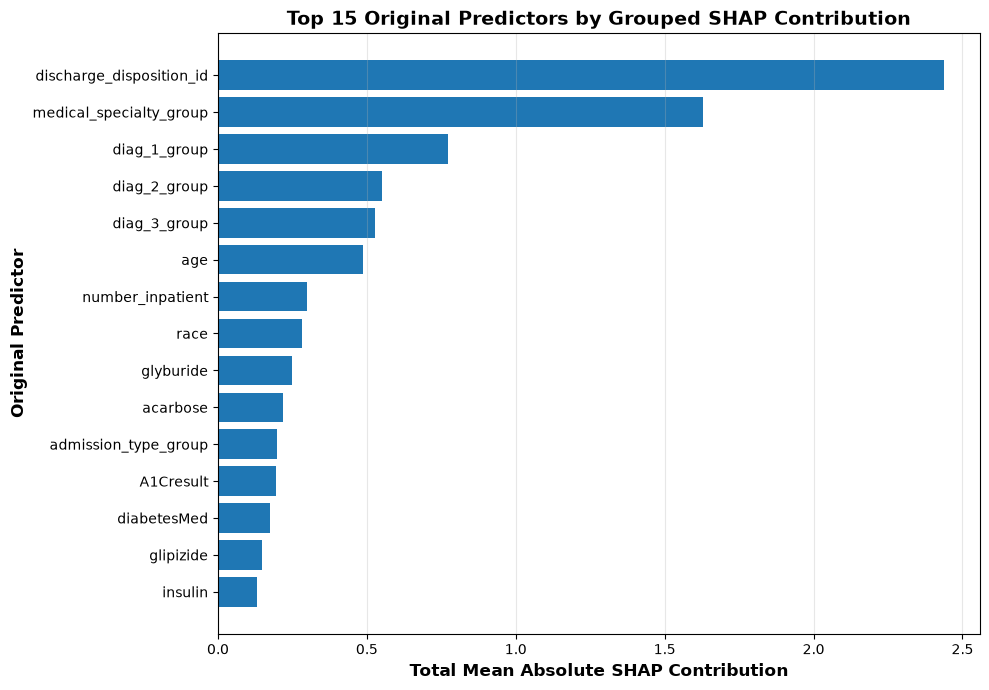


Grouped SHAP outputs saved successfully.
CSV: C:\Users\pradh\Documents\hospital-readmission-project\outputs\metrics\notebook_8_grouped_original_shap_importance.csv
Plot: C:\Users\pradh\Documents\hospital-readmission-project\outputs\figures\notebook_8_top_15_grouped_original_shap_importance.png


In [6]:
# Step 5: Group SHAP contributions by original predictor

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Helper function to map transformed feature to original feature

def get_original_feature_name(transformed_feature):
    feature = str(transformed_feature)

    # Remove preprocessing prefixes
    feature = feature.replace("numeric__", "")
    feature = feature.replace("categorical__", "")

    # Numeric features stay as-is
    if feature in numeric_features:
        return feature

    # Match one-hot encoded categorical features back to original column
    for original_feature in sorted(categorical_features, key=len, reverse=True):
        if feature == original_feature:
            return original_feature

        if feature.startswith(original_feature + "_"):
            return original_feature

    return feature

# 2. Add original feature names to SHAP table

shap_grouped_df = shap_importance_df.copy()

shap_grouped_df["original_feature"] = (
    shap_grouped_df["feature"]
    .apply(get_original_feature_name)
)

# 3. Aggregate SHAP importance by original feature

original_shap_importance = (
    shap_grouped_df
    .groupby("original_feature", as_index=False)
    .agg(
        total_mean_absolute_shap=("mean_absolute_shap", "sum"),
        max_single_mean_absolute_shap=("mean_absolute_shap", "max"),
        mean_shap=("mean_shap", "mean"),
        number_transformed_features=("feature", "count")
    )
    .sort_values("total_mean_absolute_shap", ascending=False)
    .reset_index(drop=True)
)

original_shap_importance["rank"] = (
    original_shap_importance.index + 1
)

original_shap_importance = original_shap_importance[
    [
        "rank",
        "original_feature",
        "total_mean_absolute_shap",
        "max_single_mean_absolute_shap",
        "mean_shap",
        "number_transformed_features",
    ]
]

# 4. Save grouped SHAP importance table

grouped_shap_path = (
    METRICS_PATH
    / "notebook_8_grouped_original_shap_importance.csv"
)

original_shap_importance.to_csv(
    grouped_shap_path,
    index=False
)

print("Top original predictors by grouped SHAP contribution")
print("-" * 100)

print(
    original_shap_importance
    .head(25)
    .round(6)
    .to_string(index=False)
)

# 5. Plot top 15 original predictors by SHAP contribution

top_n = 15

top_original_shap = (
    original_shap_importance
    .head(top_n)
    .sort_values("total_mean_absolute_shap", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    top_original_shap["original_feature"],
    top_original_shap["total_mean_absolute_shap"]
)

ax.set_title(
    "Top 15 Original Predictors by Grouped SHAP Contribution",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Total Mean Absolute SHAP Contribution",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Original Predictor",
    fontsize=12,
    fontweight="bold"
)

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()

grouped_shap_plot_path = (
    FIGURES_PATH
    / "notebook_8_top_15_grouped_original_shap_importance.png"
)

plt.savefig(
    grouped_shap_plot_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# 6. Print saved locations

print("\nGrouped SHAP outputs saved successfully.")
print(f"CSV: {grouped_shap_path}")
print(f"Plot: {grouped_shap_plot_path}")

### Grouped SHAP Interpretation

The grouped SHAP analysis shows that the final Tuned XGBoost model is most influenced by discharge disposition, medical specialty group, diagnosis groups, age, and prior inpatient history.

`discharge_disposition_id` had the highest total SHAP contribution, suggesting that discharge status or discharge destination strongly affects the model’s readmission risk predictions. `medical_specialty_group` was the second most influential predictor, indicating that the type of specialty care involved provides useful information for readmission risk.

Diagnosis-related variables, including `diag_1_group`, `diag_2_group`, and `diag_3_group`, were also among the most important predictors. This shows that the patient’s medical condition categories play a major role in the model’s decision-making. Age and previous inpatient visits were also important, which is clinically reasonable because older patients and patients with prior hospital utilization may have higher readmission risk.

Overall, the SHAP results support that the model is using meaningful healthcare-related predictors. However, these results should be interpreted as model explanations, not direct medical causation.

Selected high-risk test encounter
--------------------------------------------------------------------------------
Test row position: 11781
Predicted readmission probability: 0.9570
Prediction at threshold 0.45: 1
Actual readmitted_30 value: 0

Top 15 SHAP contributions for selected high-risk patient
----------------------------------------------------------------------------------------------------
                                                             feature         original_feature  shap_value  absolute_shap_value
                                           numeric__number_inpatient         number_inpatient    1.776013             1.776013
                             categorical__discharge_disposition_id_2 discharge_disposition_id    0.612940             0.612940
                             categorical__discharge_disposition_id_9 discharge_disposition_id    0.330728             0.330728
                                 categorical__diag_2_group_Neoplasms             diag_2_g

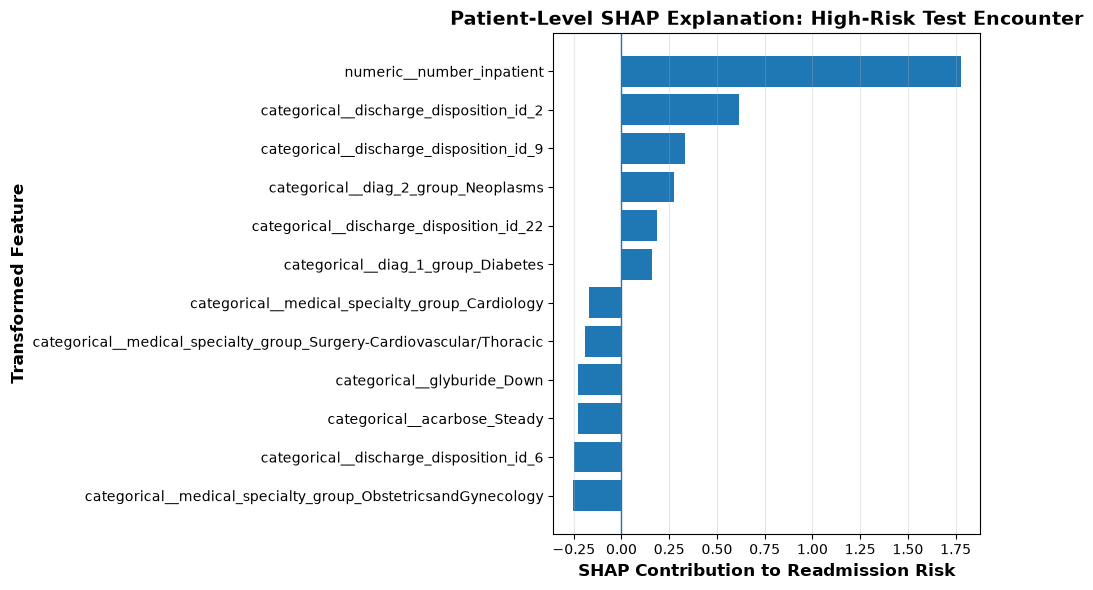


Selected patient SHAP explanation saved successfully.
CSV: C:\Users\pradh\Documents\hospital-readmission-project\outputs\metrics\notebook_8_selected_high_risk_patient_shap_explanation.csv
Plot: C:\Users\pradh\Documents\hospital-readmission-project\outputs\figures\notebook_8_selected_high_risk_patient_shap_explanation.png


In [7]:
# Step 6: Individual patient-level SHAP explanation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate final model probabilities for test set

test_probabilities = final_model.predict_proba(X_test_preprocessed)[:, 1]

# Use recall-focused threshold because professor recommended it as a clinical screening option
screening_threshold = 0.45

test_predictions_045 = (
    test_probabilities >= screening_threshold
).astype(int)

# 2. Select one high-risk patient example
# Pick the highest predicted risk case from the test set.

selected_position = int(np.argmax(test_probabilities))

selected_probability = test_probabilities[selected_position]
selected_actual = y_test.iloc[selected_position]
selected_prediction = test_predictions_045[selected_position]

print("Selected high-risk test encounter")
print("-" * 80)
print(f"Test row position: {selected_position}")
print(f"Predicted readmission probability: {selected_probability:.4f}")
print(f"Prediction at threshold 0.45: {selected_prediction}")
print(f"Actual readmitted_30 value: {selected_actual}")


# 3. Extract SHAP values for selected patient

selected_shap_values = shap_values[selected_position]

selected_patient_shap = pd.DataFrame(
    {
        "feature": transformed_feature_names,
        "shap_value": selected_shap_values,
        "absolute_shap_value": np.abs(selected_shap_values),
    }
)

selected_patient_shap["original_feature"] = (
    selected_patient_shap["feature"]
    .apply(get_original_feature_name)
)

selected_patient_shap = (
    selected_patient_shap
    .sort_values("absolute_shap_value", ascending=False)
    .reset_index(drop=True)
)

# 4. Save selected patient SHAP explanation

selected_patient_shap_path = (
    METRICS_PATH
    / "notebook_8_selected_high_risk_patient_shap_explanation.csv"
)

selected_patient_shap.to_csv(
    selected_patient_shap_path,
    index=False
)

print("\nTop 15 SHAP contributions for selected high-risk patient")
print("-" * 100)

print(
    selected_patient_shap[
        [
            "feature",
            "original_feature",
            "shap_value",
            "absolute_shap_value",
        ]
    ]
    .head(15)
    .round(6)
    .to_string(index=False)
)

# 5. Plot top 12 patient-level SHAP contributions

top_patient_features = (
    selected_patient_shap
    .head(12)
    .sort_values("shap_value", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_patient_features["feature"],
    top_patient_features["shap_value"]
)

ax.axvline(
    0,
    linewidth=1
)

ax.set_title(
    "Patient-Level SHAP Explanation: High-Risk Test Encounter",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "SHAP Contribution to Readmission Risk",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Transformed Feature",
    fontsize=12,
    fontweight="bold"
)

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()

selected_patient_shap_plot_path = (
    FIGURES_PATH
    / "notebook_8_selected_high_risk_patient_shap_explanation.png"
)

plt.savefig(
    selected_patient_shap_plot_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# 6. Print saved locations

print("\nSelected patient SHAP explanation saved successfully.")
print(f"CSV: {selected_patient_shap_path}")
print(f"Plot: {selected_patient_shap_plot_path}")

Selected true positive high-risk test encounter
--------------------------------------------------------------------------------
Test row position: 13506
Predicted readmission probability: 0.9556
Prediction at threshold 0.45: 1
Actual readmitted_30 value: 1

Top 15 SHAP contributions for selected true positive patient
----------------------------------------------------------------------------------------------------
                                                             feature         original_feature  shap_value  absolute_shap_value
                                           numeric__number_inpatient         number_inpatient    1.768217             1.768217
                             categorical__discharge_disposition_id_2 discharge_disposition_id    0.621025             0.621025
                             categorical__discharge_disposition_id_9 discharge_disposition_id    0.320550             0.320550
        categorical__medical_specialty_group_ObstetricsandGynecology  m

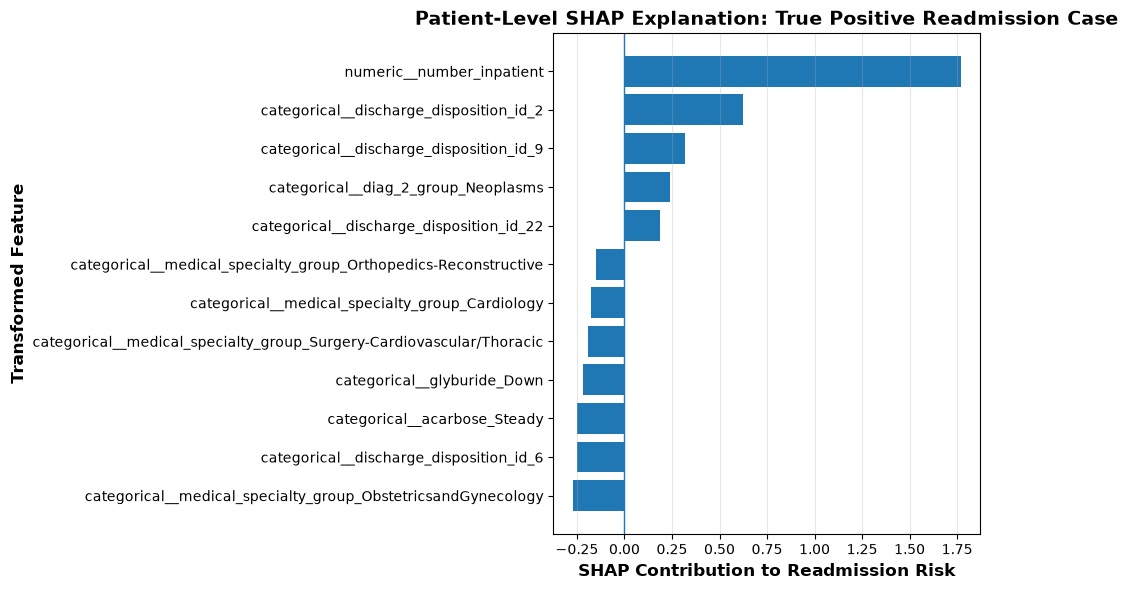


True positive patient SHAP explanation saved successfully.
CSV: C:\Users\pradh\Documents\hospital-readmission-project\outputs\metrics\notebook_8_true_positive_patient_shap_explanation.csv
Plot: C:\Users\pradh\Documents\hospital-readmission-project\outputs\figures\notebook_8_true_positive_patient_shap_explanation.png


In [ ]:
# Step 6B: Individual SHAP explanation for a true positive patient

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Use recall-focused threshold

screening_threshold = 0.45

test_probabilities = final_model.predict_proba(X_test_preprocessed)[:, 1]

test_predictions_045 = (
    test_probabilities >= screening_threshold
).astype(int)

# 2. Find true positive cases
# True positive = actual readmitted and model predicted readmitted

true_positive_mask = (
    (y_test.values == 1) &
    (test_predictions_045 == 1)
)

true_positive_positions = np.where(true_positive_mask)[0]

if len(true_positive_positions) == 0:
    raise ValueError("No true positive cases found at threshold 0.45.")

# Select the true positive case with the highest predicted probability
selected_position = true_positive_positions[
    np.argmax(test_probabilities[true_positive_positions])
]

selected_probability = test_probabilities[selected_position]
selected_actual = y_test.iloc[selected_position]
selected_prediction = test_predictions_045[selected_position]

print("Selected true positive high-risk test encounter")
print("-" * 80)
print(f"Test row position: {selected_position}")
print(f"Predicted readmission probability: {selected_probability:.4f}")
print(f"Prediction at threshold 0.45: {selected_prediction}")
print(f"Actual readmitted_30 value: {selected_actual}")


# 3. Extract SHAP values for selected true positive patient

selected_shap_values = shap_values[selected_position]

selected_true_positive_shap = pd.DataFrame(
    {
        "feature": transformed_feature_names,
        "shap_value": selected_shap_values,
        "absolute_shap_value": np.abs(selected_shap_values),
    }
)

selected_true_positive_shap["original_feature"] = (
    selected_true_positive_shap["feature"]
    .apply(get_original_feature_name)
)

selected_true_positive_shap = (
    selected_true_positive_shap
    .sort_values("absolute_shap_value", ascending=False)
    .reset_index(drop=True)
)

# 4. Save selected true positive SHAP explanation

selected_true_positive_shap_path = (
    METRICS_PATH
    / "notebook_8_true_positive_patient_shap_explanation.csv"
)

selected_true_positive_shap.to_csv(
    selected_true_positive_shap_path,
    index=False
)

print("\nTop 15 SHAP contributions for selected true positive patient")
print("-" * 100)

print(
    selected_true_positive_shap[
        [
            "feature",
            "original_feature",
            "shap_value",
            "absolute_shap_value",
        ]
    ]
    .head(15)
    .round(6)
    .to_string(index=False)
)

# 5. Plot top 12 patient-level SHAP contributions

top_true_positive_features = (
    selected_true_positive_shap
    .head(12)
    .sort_values("shap_value", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_true_positive_features["feature"],
    top_true_positive_features["shap_value"]
)

ax.axvline(
    0,
    linewidth=1
)

ax.set_title(
    "Patient-Level SHAP Explanation: True Positive Readmission Case",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "SHAP Contribution to Readmission Risk",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Transformed Feature",
    fontsize=12,
    fontweight="bold"
)

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()

selected_true_positive_shap_plot_path = (
    FIGURES_PATH
    / "notebook_8_true_positive_patient_shap_explanation.png"
)

plt.savefig(
    selected_true_positive_shap_plot_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# 6. Print saved locations

print("\nTrue positive patient SHAP explanation saved successfully.")
print(f"CSV: {selected_true_positive_shap_path}")
print(f"Plot: {selected_true_positive_shap_plot_path}")

### Patient-Level SHAP Interpretation

A true positive high-risk patient was selected to explain how the final Tuned XGBoost model makes an individual prediction. This patient had a predicted readmission probability of 95.56% and was correctly classified as high risk at the 0.45 recall-focused threshold. The actual outcome was also readmitted within 30 days.

The strongest positive contributor was `number_inpatient`, meaning the patient’s prior inpatient visit history strongly increased the model’s predicted readmission risk. Several discharge disposition features also contributed to the prediction, showing that the patient’s discharge status or destination influenced the model’s decision. Diagnosis-related features also contributed, suggesting that the patient’s medical condition category was important for this prediction.

Some features had negative SHAP values, meaning they reduced the predicted readmission risk for this specific patient. However, the positive risk-driving features outweighed the negative contributions, resulting in a high-risk prediction.

This patient-level explanation helps show how the model can support clinical risk screening by identifying which features pushed an individual prediction toward higher readmission risk. The explanation should be interpreted as model reasoning, not direct medical causation.

In [ ]:
# Force restore true positive patient values

import numpy as np
import pandas as pd

# 1. Reload true positive SHAP explanation

true_positive_shap_path = (
    METRICS_PATH
    / "notebook_8_true_positive_patient_shap_explanation.csv"
)

if not true_positive_shap_path.exists():
    raise FileNotFoundError(
        "True positive SHAP file not found. Please rerun Step 6B."
    )

selected_true_positive_shap = pd.read_csv(true_positive_shap_path)

# 2. Force recompute true positive selected patient

screening_threshold = 0.45

test_probabilities = final_model.predict_proba(X_test_preprocessed)[:, 1]
test_predictions_045 = (test_probabilities >= screening_threshold).astype(int)

true_positive_mask = (
    (y_test.values == 1) &
    (test_predictions_045 == 1)
)

true_positive_positions = np.where(true_positive_mask)[0]

if len(true_positive_positions) == 0:
    raise ValueError("No true positive cases found at threshold 0.45.")

selected_position = true_positive_positions[
    np.argmax(test_probabilities[true_positive_positions])
]

selected_probability = test_probabilities[selected_position]
selected_prediction = test_predictions_045[selected_position]
selected_actual = y_test.iloc[selected_position]

# 3. Confirm corrected values

print("True positive patient values restored.")
print("-" * 80)
print(f"Selected position: {selected_position}")
print(f"Predicted probability: {selected_probability:.4f}")
print(f"Prediction: {selected_prediction}")
print(f"Actual: {selected_actual}")

if selected_actual != 1:
    raise ValueError("Still not a true positive. Do not continue.")

print("\nConfirmed: selected patient is a true positive.")

True positive patient values restored.
--------------------------------------------------------------------------------
Selected position: 13506
Predicted probability: 0.9556
Prediction: 1
Actual: 1

Confirmed: selected patient is a true positive.


In [13]:
# ============================================================
# Notebook 8: Recovery Cell before Step 7
# Define selected_true_positive_shap if missing
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

true_positive_shap_path = (
    METRICS_PATH
    / "notebook_8_true_positive_patient_shap_explanation.csv"
)

if "selected_true_positive_shap" not in globals():

    if true_positive_shap_path.exists():
        selected_true_positive_shap = pd.read_csv(true_positive_shap_path)
        print("Loaded selected_true_positive_shap from saved CSV.")

    else:
        raise FileNotFoundError(
            "selected_true_positive_shap is missing and the saved CSV was not found. "
            "Please rerun Step 6B first."
        )

# Also restore selected patient summary values if missing
if (
    "selected_position" not in globals()
    or "selected_probability" not in globals()
    or "selected_prediction" not in globals()
    or "selected_actual" not in globals()
):
    screening_threshold = 0.45

    test_probabilities = final_model.predict_proba(X_test_preprocessed)[:, 1]
    test_predictions_045 = (test_probabilities >= screening_threshold).astype(int)

    true_positive_mask = (
        (y_test.values == 1) &
        (test_predictions_045 == 1)
    )

    true_positive_positions = np.where(true_positive_mask)[0]

    selected_position = true_positive_positions[
        np.argmax(test_probabilities[true_positive_positions])
    ]

    selected_probability = test_probabilities[selected_position]
    selected_prediction = test_predictions_045[selected_position]
    selected_actual = y_test.iloc[selected_position]

    print("Restored selected true positive patient summary values.")

print("Recovery completed.")
print(f"Selected position: {selected_position}")
print(f"Predicted probability: {selected_probability:.4f}")
print(f"Prediction: {selected_prediction}")
print(f"Actual: {selected_actual}")

Recovery completed.
Selected position: 13506
Predicted probability: 0.9556
Prediction: 1
Actual: 1
